# Lab 2: Classification

## Decision and Machine Learning, Centrale Lille

In this lab, we tackle a binary classification problem on the MNIST dataset, which contains 28x28 images of handwritten digits. More precisely, our goal is to distinguish 3s from 5s using logistic regression and K-nearest neighbors.

**Report by Ugo Roccamatisi.**


In [1]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

**Q1.** Load the data from the `.npy` files in this folder (use `np.load`). How many examples are there? How many features? What do the values of the features represent?

In [2]:
from pathlib import Path
D3=np.load(Path('data3.npy'));D5=np.load(Path('data5.npy'))
print('3:',D3.shape,'5:',D5.shape,'intensities:',D3.min(),D3.max())

3: (1037, 784) 5: (963, 784) intensities: 0 255


**Answer.** There are 2,000 images (1,037 threes and 963 fives), each described by 784 grayscale pixels from 0 to 255.

**Q2.** Display a few examples of 3, and a few examples of 5 (use `plt.imshow`). Comment.

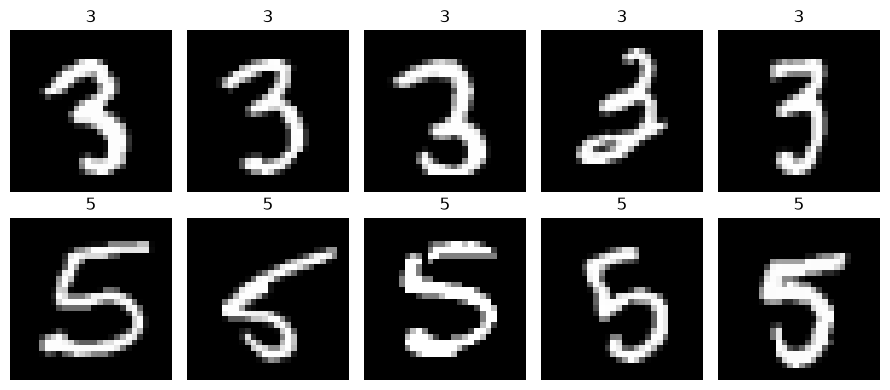

In [3]:
fig,axes=plt.subplots(2,5,figsize=(9,4))
for row,(digits,label) in enumerate(((D3,3),(D5,5))):
    for j,ax in enumerate(axes[row]):ax.imshow(digits[j].reshape(28,28),cmap='gray');ax.set_title(str(label));ax.axis('off')
fig.tight_layout();plt.show()

**Answer.** Handwriting style and stroke thickness vary; some shapes look alike, which can explain the errors.

**Q3.** Create a variable X which contains all the images (use `np.vstack`), and a variable y which encodes the class.

Normalize the features between 0 and 1.

In [4]:
X=np.vstack((D3,D5)).astype(np.float32)/255.0
y=np.r_[np.zeros(len(D3),dtype=int),np.ones(len(D5),dtype=int)]  # 0=3, 1=5.
print(X.shape,np.unique(y,return_counts=True),X.min(),X.max())

(2000, 784) (array([0, 1]), array([1037,  963])) 0.0 1.0


**Q4.** Split the dataset into a training set and a test set, using 20% of the original dataset for the test set. Do not forget to set the random state.

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=0,stratify=y)
print('Train/test:',X_train.shape,X_test.shape)

Train/test: (1600, 784) (400, 784)


**Q5.** Train a logistic regression model on the training set (see documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)). Recall how the coefficients are obtained.

What does scikit-learn do by default that does not match what we studied during the lecture ?

In [6]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=2000,random_state=0).fit(X_train,y_train)
print('Convergence:',lr.n_iter_[0],'iterations; intercept:',lr.intercept_[0])

Convergence: 53 iterations; intercept: 3.4270837


**Answer.** The parameters are obtained by numerical optimization of the penalized log-likelihood. By default, scikit-learn applies an L2 regularization (`C=1`), which is absent from the unregularized formulation seen in the lecture.

**Q6.** Compute the accuracy on the test set.

In [7]:
from sklearn.metrics import accuracy_score
pred=lr.predict(X_test)
print('Logistic regression accuracy:',accuracy_score(y_test,pred))

Logistic regression accuracy: 0.9375


**Q7.** Display the confusion matrix from the test set (add label names), and interpret it.

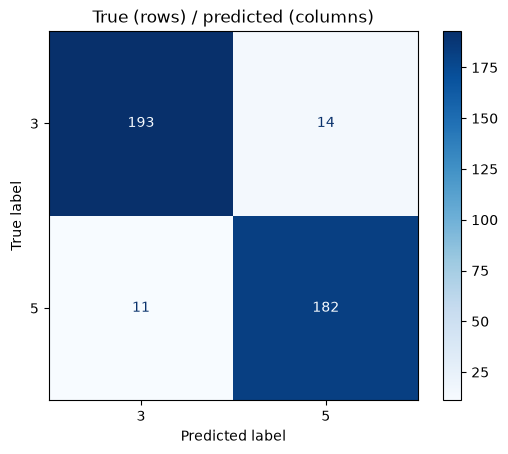

True 3s/5s correctly classified: 193 182 ; confusions 3→5 and 5→3: 14 11


In [8]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
cm=confusion_matrix(y_test,pred,labels=[0,1])
ConfusionMatrixDisplay(cm,display_labels=['3','5']).plot(cmap='Blues');plt.title('True (rows) / predicted (columns)');plt.show()
print('True 3s/5s correctly classified:',cm[0,0],cm[1,1],'; confusions 3→5 and 5→3:',cm[0,1],cm[1,0])

**Answer.** Rows are the true classes (3, then 5) and columns the predicted classes. The off-diagonal values count the two types of confusion: 14 threes predicted as 5 and 11 fives predicted as 3.

**Q8.** Display an example where a 3 was mistaken for 5, and vice versa. Comment.

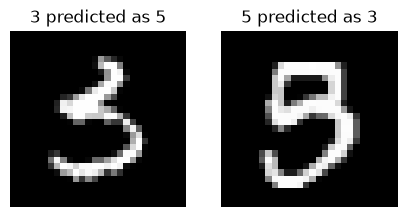

In [9]:
fig,axes=plt.subplots(1,2,figsize=(5,3))
for ax,true,predicted in zip(axes,(0,1),(1,0)):
    idx=np.flatnonzero((y_test==true)&(pred==predicted))
    if len(idx):ax.imshow(X_test[idx[0]].reshape(28,28),cmap='gray');ax.set_title(f'{[3,5][true]} predicted as {[3,5][predicted]}')
    else:ax.text(.5,.5,'No case',ha='center',va='center');ax.set_title(f'{[3,5][true]} → {[3,5][predicted]}')
    ax.axis('off')
plt.show()

**Answer.** The misclassified test images show the ambiguous shapes; if one type of error did not occur, this is shown explicitly.

**Q9.** As we have seen during the lecture, the logistic regression model does not directly output a 0 or a 1, but rather the probability of being 0 or 1 (given x), which can be accessed with the `.predict_proba` attribute. This probability is then compared to a threshold to output the prediction, the default threshold being 0.5.

Recall what is the underlying assumption of using a threshold of 0.5.

Display the evolution of the precision and recall (using the 5s as the reference class), as well as the F1-score, when the threshold varies between 0 and 1. Comment.

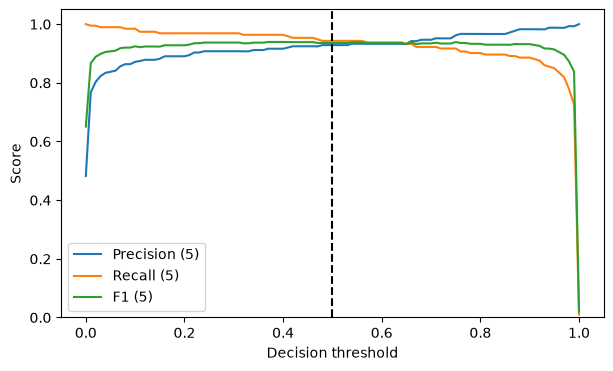

At 0.5: precision/recall/F1 [0.929 0.943 0.936]


In [10]:
from sklearn.metrics import precision_score,recall_score,f1_score
p5=lr.predict_proba(X_test)[:,1];thresholds=np.linspace(0,1,101)
values=np.array([(precision_score(y_test,p5>=t,zero_division=0),recall_score(y_test,p5>=t,zero_division=0),f1_score(y_test,p5>=t,zero_division=0)) for t in thresholds])
fig,ax=plt.subplots(figsize=(7,4))
for j,name in enumerate(('Precision (5)','Recall (5)','F1 (5)')):ax.plot(thresholds,values[:,j],label=name)
ax.axvline(.5,color='k',ls='--');ax.set(xlabel='Decision threshold',ylabel='Score',ylim=(0,1.05));ax.legend();plt.show()
print('At 0.5: precision/recall/F1',np.round(values[50],3))

**Answer.** A threshold of 0.5 assumes equal error costs for both classes, provided the probabilities are calibrated. Raising the threshold generally makes the detection of 5s more precise but less sensitive (lower recall). Scores at the extremes use `zero_division=0`.

**Q10.** Lastly, we would like to check the performance of KNN on this dataset. To do so, select the optimal value of $K$ by cross-validation on the training set, and then compute the accuracy score of the optimal KNN on the test set. Comment.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score
ks=[1,3,5,7,9,11,15]
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=0)
scores=[cross_val_score(KNeighborsClassifier(n_neighbors=k,n_jobs=-1),X_train,y_train,cv=cv,scoring='accuracy').mean() for k in ks]
chosen_k=ks[int(np.argmax(scores))]
knn=KNeighborsClassifier(n_neighbors=chosen_k,n_jobs=-1).fit(X_train,y_train)
print('CV :',list(zip(ks,np.round(scores,4))))
print(f'Best k={chosen_k}; KNN test accuracy={knn.score(X_test,y_test):.4f}; logistic={accuracy_score(y_test,pred):.4f}')

CV : [(1, np.float64(0.9706)), (3, np.float64(0.9794)), (5, np.float64(0.9781)), (7, np.float64(0.9769)), (9, np.float64(0.9794)), (11, np.float64(0.98)), (15, np.float64(0.9781))]
Best k=11; KNN test accuracy=0.9700; logistic=0.9375


**Answer.** k is chosen on the training set only. KNN with k=11 reaches 97.0% test accuracy against 93.75% for logistic regression, on the same test set, which was never used to choose k.